In [3]:
!pip install pandas scikit-learn matplotlib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import r2_score, mean_absolute_error
print("✅ Done!")

✅ Done!


In [6]:
import urllib.request

url = "https://raw.githubusercontent.com/YBIFoundation/Dataset/main/Car%20Price.csv"
urllib.request.urlretrieve(url, "car_data.csv")
print("✅ car_data.csv downloaded!")

✅ car_data.csv downloaded!


In [7]:
df = pd.read_csv('car_data.csv')
df.dropna(inplace=True)

if 'Year' in df.columns:
    df['Car_Age'] = 2024 - df['Year']
    df.drop('Year', axis=1, inplace=True)

# Drop text columns jo useful nahi
df.drop(columns=['Brand', 'Model'], errors='ignore', inplace=True)

# Encode remaining text columns
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error
import numpy as np

X = df.drop('Selling_Price', axis=1)
y = df['Selling_Price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
preds = model.predict(X_test)

print(f"✅ R² Score: {r2_score(y_test, preds):.4f}")
print(f"✅ MAE: {mean_absolute_error(y_test, preds):.2f}")

✅ R² Score: 0.4990
✅ MAE: 169276.22


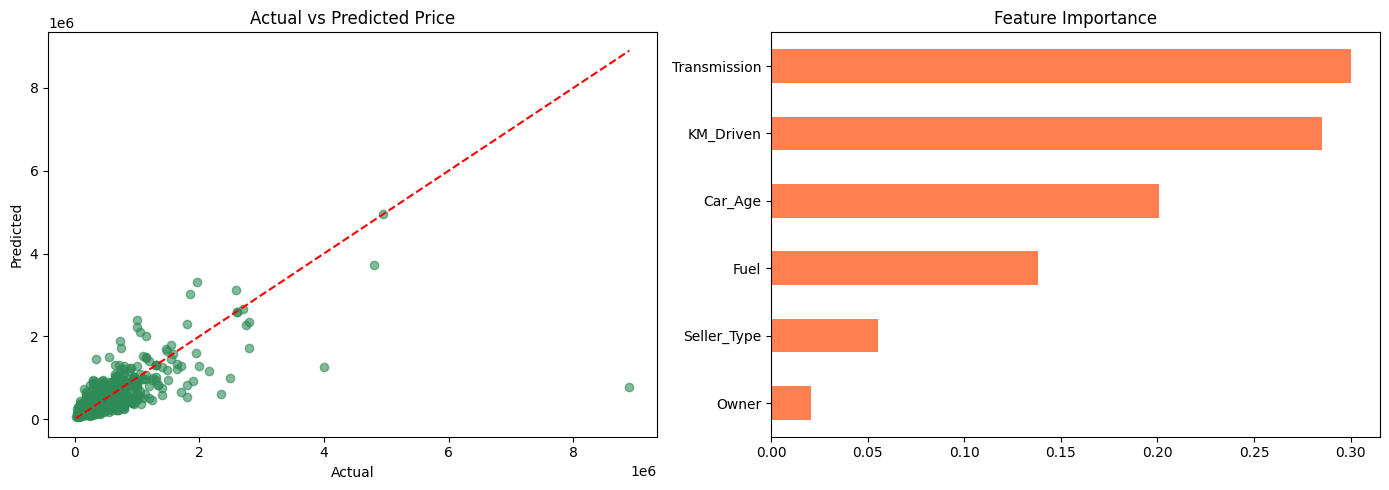

🎉 Task 3 Complete!


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Graph 1: Actual vs Predicted
axes[0].scatter(y_test, preds, alpha=0.6, color='seagreen')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
axes[0].set_title('Actual vs Predicted Price')
axes[0].set_xlabel('Actual'); axes[0].set_ylabel('Predicted')

# Graph 2: Feature Importance
feat_imp = pd.Series(model.feature_importances_, index=X.columns).sort_values()
feat_imp.plot(kind='barh', ax=axes[1], color='coral')
axes[1].set_title('Feature Importance')

plt.tight_layout()
plt.savefig('car_results.png', dpi=150)
plt.show()
print("🎉 Task 3 Complete!")